# 📈 What Drives Market Valuation in the S&P 500?

### An Exploratory Analysis of Market Capitalization, Revenue, Profitability, Valuation Multiples, and Sector Differences

**Audience:** Non-technical investors and business professionals  
**Data source:** Yahoo Finance data accessed through the `yfinance` Python package  




## Table of Contents

1. 🎯 [Business Question](#business-question)

2. 🌐 [Data Collection Using Yahoo Finance API](#data-collection-using-yahoo-finance-api)

3. 🧹 [Data Preparation and Validation](#data-preparation-and-validation)

4. 🏢 [Understand the Landscape](#understand-the-landscape)
   - [Largest Companies by Market Capitalization](#largest-companies-by-market-capitalization)
   - [Highest Revenue Companies](#highest-revenue-companies)
   - [Highest Net Income Companies](#highest-net-income-companies)
   - [Comparison of Top Companies Across Key Metrics](#comparison-of-top-companies-across-key-metrics)
     

5. 📊 [Factors Associated with Market Valuation](#factors-associated-with-market-valuation)
   - [Revenue vs. Market Capitalization](#revenue-vs-market-capitalization)
   - [Net Income vs. Market Capitalization](#net-income-vs-market-capitalization)
   - [P/E Ratio Analysis](#pe-ratio-analysis)
   - [Distribution of Market Value Across Sectors](#distribution-of-market-value-across-sectors)

7. 💡 [Key Insights](#key-insights)

8. ✅ [Conclusion](#conclusion)

## 1. 🎯 Business Question

Investors often value companies differently, even when they generate similar revenue or profits. This project investigates which financial characteristics are most closely associated with higher market valuations among S&P 500 companies. Using current financial data collected directly from the Yahoo Finance API, the analysis explores the relationships between market capitalization, revenue, profitability, P/E ratios, and industry sectors.

## 2. 🌐 Data Collection Using Yahoo Finance API

In [3]:
# Import all the necessary libraries

import time
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys 
print(sys.executable)

/Applications/anaconda3/bin/python


In [4]:
!{sys.executable} -m pip install yfinance

In [5]:
# Importing yahoo finance package
import yfinance as yf

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [102]:
retrieval_date = date.today().isoformat()

from IPython.display import Markdown, display

display(Markdown(f"**Data Retrieval Date:** {retrieval_date}"))

**Data Retrieval Date:** 2026-07-11

In [8]:
# Retrieve the current list of the S&P companies from Wikipedia

import requests
from io import StringIO
sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(
    sp500_url, 
    headers = headers, 
    timeout = 30
)
response.raise_for_status()
tables = pd.read_html(StringIO(response.text))
sp500 = tables[0].copy()
sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [9]:
# Keep only the company information needed for the analysis

sp500 = sp500[
    [
        "Symbol",
        "Security",
        "GICS Sector",
        "GICS Sub-Industry"
    ]
].copy()

sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry
0,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,Building Products
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,Accenture,Information Technology,IT Consulting & Other Services


In [10]:
# Rename the columns to shorter, Python-friendly names

sp500 = sp500.rename(
    columns={
        "Symbol": "ticker",
        "Security": "company",
        "GICS Sector": "sector",
        "GICS Sub-Industry": "industry"
    }
)

sp500.head()

,ticker,company,sector,industry
0,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,Building Products
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,Accenture,Information Technology,IT Consulting & Other Services


In [11]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    503 non-null    object
 1   company   503 non-null    object
 2   sector    503 non-null    object
 3   industry  503 non-null    object
dtypes: object(4)
memory usage: 15.8+ KB


In [12]:
# Retrieve financial information for a single company from Yahoo Finance

apple = yf.Ticker("AAPL")

apple_info = apple.info

In [13]:
apple_info.keys()

dict_keys(['address1', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'irWebsite', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 

In [14]:
apple_info

{'address1': 'One Apple Park Way',
 'city': 'Cupertino',
 'state': 'CA',
 'zip': '95014',
 'country': 'United States',
 'phone': '(408) 996-1010',
 'website': 'https://www.apple.com',
 'industry': 'Consumer Electronics',
 'industryKey': 'consumer-electronics',
 'industryDisp': 'Consumer Electronics',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download app

In [15]:
apple_info["marketCap"]

4631217307648

In [16]:
# Create an empty list that will store one dictionary for each company
company_data = []

In [17]:
for ticker in sp500["ticker"]:
    print(ticker)

MMM
AOS
ABT
ABBV
ACN
ADBE
AMD
AES
AFL
A
APD
ABNB
AKAM
ALB
ARE
ALGN
ALLE
LNT
ALL
GOOGL
GOOG
MO
AMZN
AMCR
AEE
AEP
AXP
AIG
AMT
AWK
AMP
AME
AMGN
APH
ADI
AON
APA
APO
AAPL
AMAT
APP
APTV
ACGL
ADM
ARES
ANET
AJG
AIZ
T
ATO
ADSK
ADP
AZO
AVB
AVY
AXON
BKR
BALL
BAC
BAX
BDX
BRK.B
BBY
TECH
BIIB
BLK
BX
XYZ
BNY
BA
BKNG
BSX
BMY
AVGO
BR
BRO
BF.B
BLDR
BG
BXP
CHRW
CDNS
CPT
COF
CAH
CCL
CARR
CVNA
CASY
CAT
CBOE
CBRE
CDW
COR
CNC
CNP
CF
CRL
SCHW
CHTR
CVX
CMG
CB
CHD
CIEN
CI
CINF
CTAS
CSCO
C
CFG
CLX
CME
CMS
KO
CTSH
COHR
COIN
CL
CMCSA
FIX
COP
ED
STZ
CEG
COO
CPRT
GLW
CPAY
CTVA
CSGP
COST
CRH
CRWD
CCI
CSX
CMI
CVS
DHR
DRI
DDOG
DVA
DECK
DE
DELL
DAL
DVN
DXCM
FANG
DLR
DG
DLTR
D
DPZ
DASH
DOV
DOW
DHI
DTE
DUK
DD
ETN
EBAY
ECHO
ECL
EIX
EW
EA
ELV
EME
EMR
ETR
EOG
EQT
EFX
EQIX
EQR
ERIE
ESS
EL
EG
EVRG
ES
EXC
EXE
EXPE
EXPD
EXR
XOM
FFIV
FDS
FICO
FAST
FRT
FDX
FDXF
FIS
FITB
FSLR
FE
FISV
FLEX
F
FTNT
FTV
FOXA
FOX
BEN
FCX
GRMN
IT
GE
GEHC
GEV
GEN
GNRC
GD
GIS
GM
GPC
GILD
GPN
GL
GDDY
GS
HAL
HIG
HAS
HCA
DOC
HSIC
HSY
HPE
HLT
HD
HONA
HON
HRL
H

In [18]:
# Retrieve market capitalization data from Yahoo Finance
# Use try/except to skip companies that fail to download

for ticker in sp500["ticker"]:

    try:
        stock = yf.Ticker(ticker)
        info = stock.info

        print(ticker, info.get("marketCap"))
        
    except Exception as e:
        print (f'Error retrieving {ticker}: {e}')

MMM 82157281280
AOS 8330361856
ABT 163608510464
ABBV 438305980416
ACN 82752921600
ADBE 88896897024
AMD 909695778816
AES 10540470272
AFL 62050349056
A 37927784448
APD 66699546624
ABNB 88206696448
AKAM 18346190848
ALB 14865662976
ARE 8344022528
ALGN 12851872768
ALLE 11741417472
LNT 19732365312
ALL 64769679360
GOOGL 4358514933760
GOOG 4332279300096
MO 119881490432
AMZN 2639149400064
AMCR 19964086272
AEE 31256328192
AEP 73688137728
AXP 239210004480
AIG 41976426496
AMT 78544912384
AWK 25521213440
AMP 45556248576
AME 53628919808
AMGN 196124606464
APH 195681091584
ADI 192715980800
AON 76234153984
APA 11820044288
APO 69378113536
AAPL 4631217307648
AMAT 478360567808
APP 170314629120
APTV 12817855488
ACGL 35309314048
ADM 38754123776
ARES 40178618368
ANET 235414323200
AJG 65029451776
AIZ 13818341376
T 146818383872
ATO 29411272704
ADSK 44013228032
ADP 96703717376
AZO 50161938432
AVB 27216736256
AVY 12292769792
AXON 45604655104
BKR 57103474688
BALL 16424747008
BAC 423453556736
BAX 11682529280
BDX 4

HTTP Error 500: {"finance":{"result":null,"error":{"code":"Internal Server Error","description":"Server caught an exception"}}}


GDDY 11773883392
GS 311285940224
HAL 28729327616
HIG 38043873280
HAS 11172104192
HCA 90197843968
DOC 14925936640
HSIC 9614574592
HSY 35225780224
HPE 64276840448
HLT 76371476480
HD 342310125568
HONA 69964447744
HON 71735869440
HRL 13609288704
HST 16081502208
HWM 108369117184
HPQ 22149738496
HUBB 25942140928
HUM 47090524160
HBAN 36224827392
HII 11273098240
IBM 270273413120
IEX 16443185152
IDXX 44456091648
ITW 77336633344
INCY 23316576256
IR 30856908800
PODD 11171006464
INTC 552055799808
IBKR 159597543424
ICE 76491218944
IFF 19793678336
IP 20084578304
INTU 75211726848
ISRG 144066363392
IVZ 12846736384
INVH 17583642624
IQV 34690166784
IRM 36152221696
JBHT 26400004096
JBL 34610126848
JKHY 10680354816
J 14858117120
JNJ 618606624768
JCI 87130603520
JPM 901575147520
KVUE 37401767936
KDP 43088920576
KEY 25149290496
KEYS 55036850176
KMB 37313417216
KIM 16778816512
KMI 71461404672
KKR 90390888448
KLAC 302428848128
KHC 29466574848
KR 37089669120
LHX 54168977408
LH 22698420224
LRCX 438112518144
LVS

In [26]:
# Retrieve financial information for each S&P 500 company from Yahoo Finance
company_data = [] # Create an empty list that will store one dictionary for each company
for ticker in sp500["ticker"]:
    try:
        # Request financial data for the current company
        stock = yf.Ticker(ticker)
        info = stock.info

        # Save selected financial metrics to the list
        company_data.append({
        "ticker": ticker, 
        "company": info.get("longName"), 
        "sector": info.get("sector"), 
        "industry": info.get("industry"), 
        "market_cap": info.get("marketCap"),
        "revenue": info.get("totalRevenue"),
        "net_income": info.get("netIncomeToCommon"),
        "current_price": info.get("currentPrice"),
        "pe_ratio": info.get("trailingPE")
        })
    except Exception as e:
        # Skip companies whose data cannot be retrieved
        print(f'Error retrieving {ticker}: {e}')

Error retrieving CDW: Failed to perform, curl: (28) Operation timed out after 30004 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
Error retrieving INTC: Failed to perform, curl: (28) Operation timed out after 30004 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


In [27]:
# Convert the collected financial data into a pandas DataFrame
financial_df = pd.DataFrame(company_data)

In [21]:
financial_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ticker         502 non-null    object 
 1   company        499 non-null    object 
 2   sector         499 non-null    object 
 3   industry       499 non-null    object 
 4   market_cap     500 non-null    float64
 5   revenue        499 non-null    float64
 6   net_income     498 non-null    float64
 7   current_price  500 non-null    float64
 8   pe_ratio       475 non-null    float64
dtypes: float64(5), object(4)
memory usage: 35.4+ KB


In [22]:
financial_df.head(10)

,ticker,company,sector,industry,market_cap,revenue,net_income,current_price,pe_ratio
0,MMM,3M Company,Industrials,Conglomerates,"82,157,281,280.00","25,024,000,000.00","2,787,000,064.00",157.52,30.41
1,AOS,A. O. Smith Corporation,Industrials,Specialty Industrial Machinery,"8,330,361,856.00","3,811,899,904.00","527,600,000.00",60.44,16.12
2,ABT,Abbott Laboratories,Healthcare,Medical Devices,"163,608,510,464.00","45,134,000,128.00","6,252,000,256.00",93.93,26.31
3,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,"438,305,980,416.00","62,819,000,320.00","3,595,000,064.00",248.08,122.21
4,ACN,Accenture plc,Technology,Information Technology Services,"82,752,921,600.00","73,100,591,104.00","7,789,751,808.00",135.23,10.80
5,ADBE,Adobe Inc.,Technology,Software - Application,"88,896,897,024.00","25,198,000,128.00","7,229,000,192.00",223.64,12.79
6,AMD,"Advanced Micro Devices, Inc.",Technology,Semiconductors,"909,695,778,816.00","37,454,000,128.00","4,931,999,744.00",557.89,185.35
7,AES,The AES Corporation,Utilities,Utilities - Diversified,"10,540,470,272.00","12,487,000,064.00","1,380,000,000.00",14.78,7.70
8,AFL,Aflac Incorporated,Financial Services,Insurance - Life,"62,050,349,056.00","18,112,000,000.00","4,636,000,256.00",121.91,13.93
9,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,"37,927,784,448.00","7,232,000,000.00","1,414,000,000.00",134.29,26.97


In [23]:
financial_df.describe()

,market_cap,revenue,net_income,current_price,pe_ratio
count,500.00,499.00,498.00,500.00,475.00
mean,"144,890,664,117.25","37,329,702,669.85","4,964,929,448.53",238.97,38.46
std,"472,591,057,313.59","76,948,809,792.78","16,087,255,044.32",392.71,52.99
min,"6,836,881,408.00","839,025,024.00","-14,441,396,224.00",9.41,3.54
25%,"22,881,494,528.00","7,180,999,936.00","828,536,752.00",77.85,18.16
50%,"44,765,591,552.00","14,721,000,448.00","1,642,350,016.00",140.53,26.50
75%,"93,864,747,008.00","30,148,075,520.00","3,702,242,944.00",274.38,37.83
max,"5,109,662,089,216.00","742,775,980,032.00","160,207,994,880.00","6,479.39",660.36


In [24]:
# Save the collected data to a CSV file
financial_df.to_csv("sp500_financial_data.csv", index=False)

## 3. 🧹 Data Preparation and Validation

### 3.1 Missing Value Analysis

In [25]:
# Check for missing values in each column
financial_df.isnull().sum()

ticker            0
company           3
sector            3
industry          3
market_cap        2
revenue           3
net_income        4
current_price     2
pe_ratio         27
dtype: int64

In [28]:
financial_df[financial_df.isnull().any(axis=1)]

,ticker,company,sector,industry,market_cap,revenue,net_income,current_price,pe_ratio
13,ALB,Albemarle Corporation,Basic Materials,Specialty Chemicals,"14,865,662,976.00","5,494,582,784.00","-399,635,008.00",126.05,NaN
14,ARE,"Alexandria Real Estate Equities, Inc.",Real Estate,REIT - Office,"8,344,022,528.00","2,930,149,120.00","-1,067,513,984.00",47.88,NaN
59,BAX,Baxter International Inc.,Healthcare,Medical Instruments & Supplies,"11,682,529,280.00","11,320,000,512.00","-981,000,000.00",22.62,NaN
61,BRK.B,None,None,None,NaN,NaN,NaN,NaN,NaN
68,BNY,None,Financial Services,Banks - Diversified,"104,274,706,432.00","20,753,999,872.00","5,719,000,064.00",151.92,18.83
76,BF.B,None,None,None,NaN,NaN,NaN,NaN,NaN
93,CNC,Centene Corporation,Healthcare,Healthcare Plans,"33,257,226,240.00","178,331,992,064.00","-6,444,000,256.00",67.35,NaN
96,CRL,"Charles River Laboratories International, Inc.",Healthcare,Diagnostics & Research,"11,242,829,824.00","4,027,044,096.00","-184,650,000.00",233.41,NaN
132,CRWD,"CrowdStrike Holdings, Inc.",Technology,Software - Infrastructure,"190,597,758,976.00","5,094,199,808.00","-30,464,000.00",187.18,NaN
155,DOW,Dow Inc.,Basic Materials,Chemicals,"20,923,123,712.00","39,331,000,320.00","-2,859,000,064.00",29.03,NaN


In [29]:
financial_df[financial_df["revenue"].isnull()]

,ticker,company,sector,industry,market_cap,revenue,net_income,current_price,pe_ratio
61,BRK.B,None,None,None,NaN,NaN,NaN,NaN,NaN
76,BF.B,None,None,None,NaN,NaN,NaN,NaN,NaN
199,FISV,"Fiserv, Inc.",None,None,"26,902,663,168.00",NaN,NaN,50.45,8.55


In [30]:
financial_df[financial_df["net_income"].isnull()]

,ticker,company,sector,industry,market_cap,revenue,net_income,current_price,pe_ratio
61,BRK.B,None,None,None,NaN,NaN,NaN,NaN,NaN
76,BF.B,None,None,None,NaN,NaN,NaN,NaN,NaN
199,FISV,"Fiserv, Inc.",None,None,"26,902,663,168.00",NaN,NaN,50.45,8.55
359,PAYX,"Paychex, Inc.",Technology,Software - Application,"38,241,222,656.00","3,968,000,000.00",NaN,107.54,21.99


In [31]:
# Remove companies with missing core company information
financial_df = financial_df.dropna(
    subset=["company", "sector", "industry"]
)

In [32]:
financial_df.isnull().sum()

ticker            0
company           0
sector            0
industry          0
market_cap        0
revenue           0
net_income        1
current_price     0
pe_ratio         24
dtype: int64

In [34]:
payx = yf.Ticker("PAYX")
print(payx.info.get("netIncomeToCommon"))

None


### *Missing Value Summary*: 
After removing three observations with missing company information (company name, sector, and industry), the dataset contained one remaining missing value for net_income and 24 missing values for pe_ratio. The missing net_income value was retained because it reflects an unavailable field from the Yahoo Finance API rather than a data processing error. The missing pe_ratio values were also retained because they primarily correspond to companies reporting negative earnings, for which Yahoo Finance does not assign a numeric P/E ratio. These observations were preserved to maintain a representative sample of S&P 500 companies.

## 4. 🏢 Company Size and Financial Performance

This section provides an overview of the largest S&P 500 companies based on market capitalization, revenue, and net income. These descriptive statistics establish the context for the subsequent analysis of the factors associated with company valuation.

## Largest Companies by Market Capitalization

In [38]:
# Select the 10 largest companies by market capitalization
top_market_cap = (
    financial_df
    .nlargest(10, "market_cap")                   # selects the 10 largest
    .sort_values("market_cap", ascending = False) # sorts them from smallest to largest
)

top_market_cap[["company", "market_cap"]]

,company,market_cap
342,NVIDIA Corporation,"5,109,662,089,216.00"
38,Apple Inc.,"4,631,217,307,648.00"
19,Alphabet Inc.,"4,358,514,933,760.00"
20,Alphabet Inc.,"4,332,279,300,096.00"
314,Microsoft Corporation,"2,860,690,440,192.00"
22,"Amazon.com, Inc.","2,639,149,400,064.00"
73,Broadcom Inc.,"1,902,889,402,368.00"
308,"Meta Platforms, Inc.","1,698,738,339,840.00"
436,"Tesla, Inc.","1,531,433,975,808.00"
313,"Micron Technology, Inc.","1,106,014,765,056.00"


***Note***: Alphabet appears twice in the dataset because both Class A (GOOGL) and Class C (GOOG) shares are constituents of the S&P 500. They are retained as separate observations to remain consistent with the index composition.

In [39]:
top_market_cap["label"] = (
    top_market_cap["company"] +
    "(" +
    top_market_cap["ticker"] +
    ")"
)

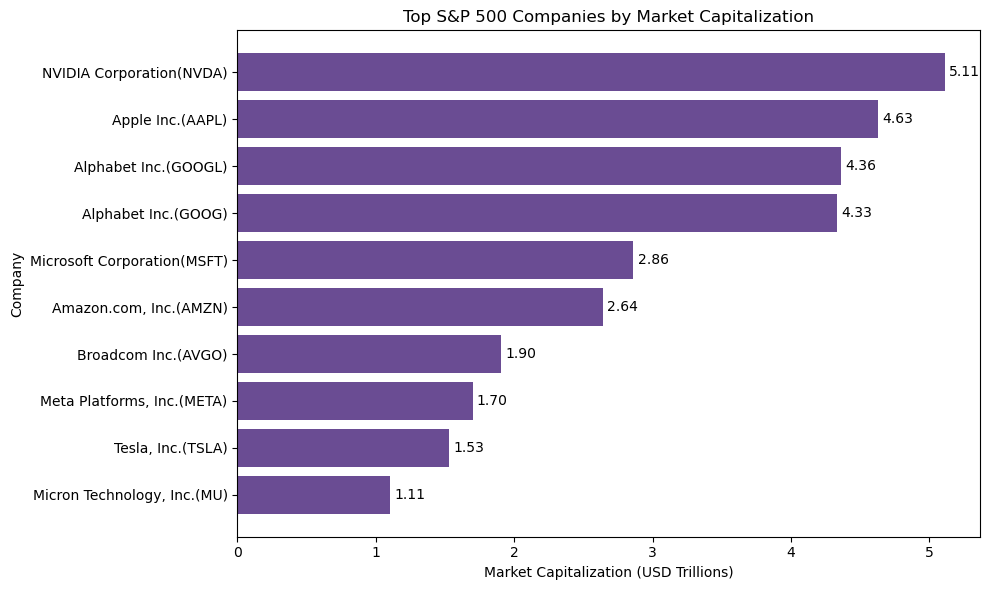

In [57]:
# Visualize the 10 largest companies by market capitalization

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_market_cap["label"],
    top_market_cap["market_cap"] / 1e12,
    color = "#6A4C93"
)

plt.gca().invert_yaxis()
plt.title("Top S&P 500 Companies by Market Capitalization")
plt.xlabel("Market Capitalization (USD Trillions)")
plt.ylabel("Company")

plt.bar_label(
    bars,
    fmt="%.2f",
    padding=3
    
)

plt.tight_layout()
plt.show()

NVIDIA and Apple have the highest market capitalizations among the S&P 500 companies in the dataset. The rankings are heavily concentrated in technology-related firms, indicating that investors assign especially high valuations to companies associated with artificial intelligence, cloud computing, digital platforms, and semiconductors. Alphabet appears twice because both GOOG and GOOGL are separate S&P 500 share classes.

## Highest Revenue Companies

In [53]:
# Select the 10 companies with the highest revenue
top_revenue = (
    financial_df
    .nlargest(10, "revenue")
    .sort_values("revenue", ascending = False)
)

top_revenue[["company", "ticker", "revenue"]]

,company,ticker,revenue
22,"Amazon.com, Inc.",AMZN,"742,775,980,032.00"
479,Walmart Inc.,WMT,"725,304,999,936.00"
38,Apple Inc.,AAPL,"451,442,016,256.00"
460,UnitedHealth Group Incorporated,UNH,"449,713,012,736.00"
19,Alphabet Inc.,GOOGL,"422,498,009,088.00"
20,Alphabet Inc.,GOOG,"422,498,009,088.00"
136,CVS Health Corporation,CVS,"405,617,999,872.00"
305,McKesson Corporation,MCK,"403,430,014,976.00"
92,"Cencora, Inc.",COR,"328,680,013,824.00"
187,ExxonMobil Holdings Corporation,XOM,"326,008,012,800.00"


In [54]:
# Prepare the data for a horizontal bar chart
plot_revenue = top_revenue.sort_values("revenue").copy()

plot_revenue["label"] = (
    plot_revenue["company"] + " (" + plot_revenue["ticker"] + ")"
)

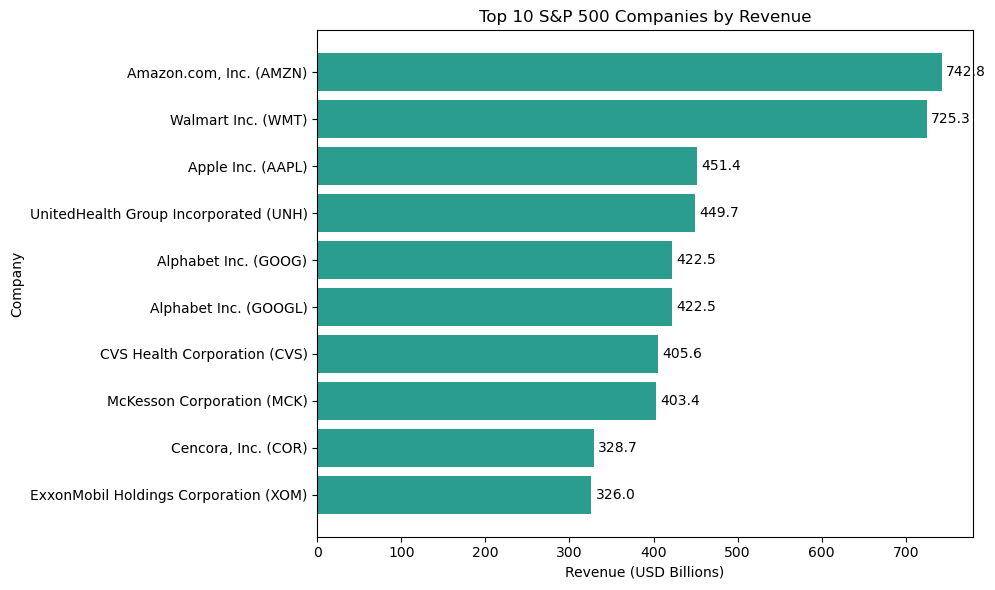

In [71]:
# Visualize the 10 companies with the highest revenue
plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_revenue["label"],
    plot_revenue["revenue"] / 1e9,
    color="#2A9D8F"
)

plt.title("Top 10 S&P 500 Companies by Revenue")
plt.xlabel("Revenue (USD Billions)")
plt.ylabel("Company")

plt.bar_label(
    bars,
    fmt="%.1f",
    padding=3,
    color="black"
)

plt.tight_layout()
plt.show()

### Key Observations

- **Amazon** generates the highest annual revenue among S&P 500 companies, followed closely by **Walmart**

- Although **Amazon** leads in revenue, it does **not** have the largest market capitalization. In the previous analysis, **NVIDIA** ranked first in market value despite generating substantially lower revenue.

- **Walmart**, the second-highest revenue company, does not appear among the ten largest companies by market capitalization, highlighting that large sales alone do not determine a company's market value.

- Technology companies such as **Apple** and **Alphabet** appear near the top of both rankings, indicating that they combine strong revenue generation with high investor valuation.

- Several healthcare and distribution companies, including **UnitedHealth**, **CVS Health**, **McKesson**, and **Cencora**, generate hundreds of billions of dollars in annual revenue but have considerably lower market capitalizations than the largest technology firms.

These findings suggest that strong revenue generationalone does not determine a company's market value. The next section examines which companies generate the highest net income, providing additional insight into corporate profitability.

### Highest Net Income Companies

Net income represents a company's profit after all operating expenses, interest, taxes, and other costs have been deducted from revenue. Unlike revenue, net income reflects overall profitability and operational efficiency.

The following analysis identifies the ten S&P 500 companies with the highest reported net income.

In [58]:
# Select the 10 companies with the highest net income
top_net_income = (
    financial_df
    .nlargest(10, "net_income")
    .sort_values("net_income", ascending=False)
)

top_net_income[["company", "ticker", "net_income"]]

,company,ticker,net_income
19,Alphabet Inc.,GOOGL,"160,207,994,880.00"
20,Alphabet Inc.,GOOG,"160,207,994,880.00"
342,NVIDIA Corporation,NVDA,"159,612,993,536.00"
314,Microsoft Corporation,MSFT,"125,215,997,952.00"
38,Apple Inc.,AAPL,"122,575,003,648.00"
22,"Amazon.com, Inc.",AMZN,"90,797,998,080.00"
308,"Meta Platforms, Inc.",META,"70,586,998,784.00"
267,JPMorgan Chase & Co.,JPM,"57,512,001,536.00"
313,"Micron Technology, Inc.",MU,"50,468,999,168.00"
58,Bank of America Corporation,BAC,"30,256,001,024.00"


In [63]:
# Create labels

top_net_income["label"] = (
    top_net_income["company"] +
    " (" +
    top_net_income["ticker"] +
    ")"
)

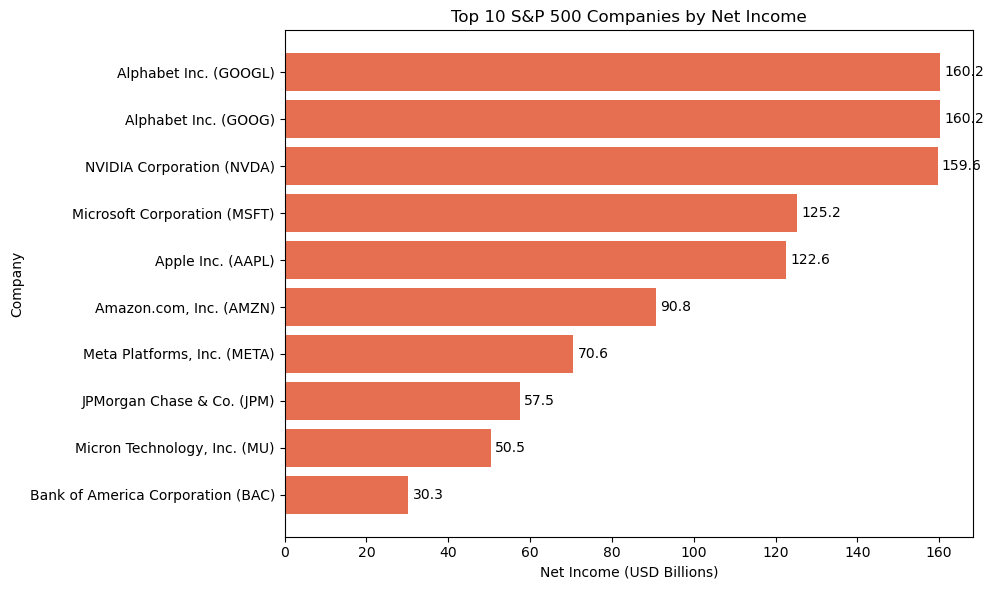

In [72]:
# Plot the horizontal bar chart
plt.figure(figsize=(10,6))

bars = plt.barh(
    top_net_income["label"],
    top_net_income["net_income"] / 1e9,
    color="#E76F51"
)

plt.title("Top 10 S&P 500 Companies by Net Income")
plt.xlabel("Net Income (USD Billions)")
plt.ylabel("Company")

plt.bar_label(
    bars,
    fmt="%.1f",
    padding=3
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Key Observations

- **Alphabet** reports the highest net income among S&P 500 companies (approximately **$160 billion**), narrowly ahead of **NVIDIA**, while **Microsoft** and **Apple** also rank among the most profitable firms.

- This visualization demonstrates that the companies generating the highest revenue are not necessarily the most profitable. For example, **Amazon** ranked first in revenue but ranks behind Alphabet, NVIDIA, Microsoft, and Apple in net income.

- **Walmart**, the second-highest revenue company, does not appear among the top ten companies by net income, illustrating that high sales volumes do not always translate into high profitability.

- Technology companies dominate the profitability rankings, with **Alphabet, NVIDIA, Microsoft, Apple, Meta,** and **Micron** accounting for most of the top positions.

- Financial institutions such as **JPMorgan Chase** and **Bank of America** also appear among the most profitable companies despite generating substantially lower revenue than many retail and healthcare firms.

## Comparison of Top Companies Across Key Metrics

In [82]:
# Create a comparison table of the top five companies by each metric

comparison_table = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Market Capitalization": top_market_cap.head(10)["company"].values,
    "Revenue": top_revenue.head(10)["company"].values,
    "Net Income": top_net_income.head(10)["company"].values
})


In [83]:
# Display the table styled by color

comparison_table.style.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("background-color", "#6A4C93"),
            ("color", "white"),
            ("font-weight", "bold")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("padding", "10px"),
            ("border", "1px solid white")
        ]
    }
]).set_properties(
    subset=["Market Capitalization"],
    **{"background-color": "#E8DDF3"}
).set_properties(
    subset=["Revenue"],
    **{"background-color": "#D9F0EC"}
).set_properties(
    subset=["Net Income"],
    **{"background-color": "#FBE2D5"}
)

,Rank,Market Capitalization,Revenue,Net Income
0,1,NVIDIA Corporation,"Amazon.com, Inc.",Alphabet Inc.
1,2,Apple Inc.,Walmart Inc.,Alphabet Inc.
2,3,Alphabet Inc.,Apple Inc.,NVIDIA Corporation
3,4,Alphabet Inc.,UnitedHealth Group Incorporated,Microsoft Corporation
4,5,Microsoft Corporation,Alphabet Inc.,Apple Inc.
5,6,"Amazon.com, Inc.",Alphabet Inc.,"Amazon.com, Inc."
6,7,Broadcom Inc.,CVS Health Corporation,"Meta Platforms, Inc."
7,8,"Meta Platforms, Inc.",McKesson Corporation,JPMorgan Chase & Co.
8,9,"Tesla, Inc.","Cencora, Inc.","Micron Technology, Inc."
9,10,"Micron Technology, Inc.",ExxonMobil Holdings Corporation,Bank of America Corporation


### *Analysis*:
This table compares the top-ranked S&P 500 companies across market capitalization, revenue, and net income. Viewing the rankings side by side highlights that leadership varies substantially depending on the financial metric being considered.
**NVIDIA** ranks first in market capitalization but not in revenue or net income.
**Amazon** generates the highest revenue but ranks lower in both market capitalization and profitability.
**Alphabet** leads in net income while also remaining among the largest companies by market capitalization.
These differences suggest that company size, sales, and profitability capture different aspects of corporate performance.

## 5. 📊 Factors Associated with Market Valuation

The previous section we identified the largest S&P 500 companies based on market capitalization, revenue, and net income. While these rankings provide useful context, they do not explain why some companies receive significantly higher market valuations than others.

In this section, we examine which financial characteristics are most closely associated with market capitalization. Specifically, we examine the relationships between revenue, net income, price-to-earnings (P/E) ratio, and company valuation, as well as differences across industry sectors.

The objective is to determine whether larger sales, higher profitability, investor expectations, or industry membership are more closely associated with higher market valuations.

## 5.1 Revenue vs. Market Capitalization

### **Do companies that generate more revenue also tend to have higher market valuations?**

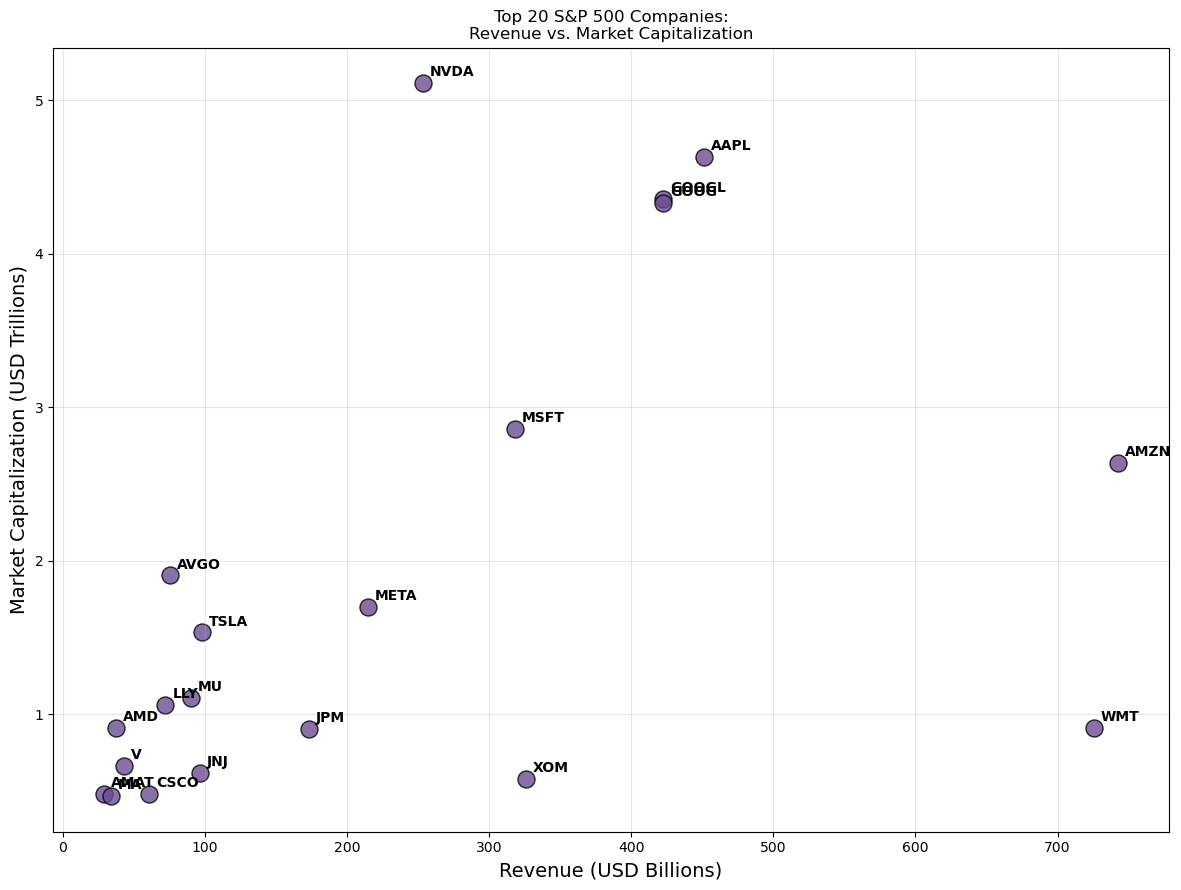

In [100]:
# Top 20 companies by market capitalization
top20 = financial_df.nlargest(20, "market_cap")

plt.figure(figsize=(12,9))

plt.scatter(
    top20["revenue"] / 1e9,
    top20["market_cap"] / 1e12,
    s=150,
    color="#6A4C93",
    edgecolors="black",
    alpha=0.8
)

# Add ticker labels
for _, row in top20.iterrows():
    plt.annotate(
        row["ticker"],
        (row["revenue"] / 1e9, row["market_cap"] / 1e12),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=10,
        fontweight = "bold"
    )

plt.title("Top 20 S&P 500 Companies:\nRevenue vs. Market Capitalization")
plt.xlabel("Revenue (USD Billions)", fontsize = 14)
plt.ylabel("Market Capitalization (USD Trillions)", fontsize = 14)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Observations

- Companies with higher revenue do not necessarily have higher market capitalizations.
- Several firms with similar revenue levels exhibit substantially different market valuations, suggesting that revenue alone does not explain how the market values a company.
- NVIDIA has the highest market capitalization despite generating considerably less revenue than Amazon and Walmart, indicating that investors value factors beyond current sales.
- Walmart generates the highest revenue among the companies shown but ranks well below NVIDIA, Apple, and Alphabet in market capitalization.
- These findings suggest that additional factors, such as profitability, expected future growth, and competitive position, likely play an important role in determining market valuation.

## 5.2 Net Income vs. Market Capitalization

### **Does higher net income translate into a higher market capitalization?**

While revenue reflects the scale of a company’s operations, net income measures how much profit remains after expenses. Because profitability is a key driver of long-term value creation, investors may place greater value on companies that consistently generate strong earnings. This section examines whether companies with higher net income also tend to have higher market capitalizations.

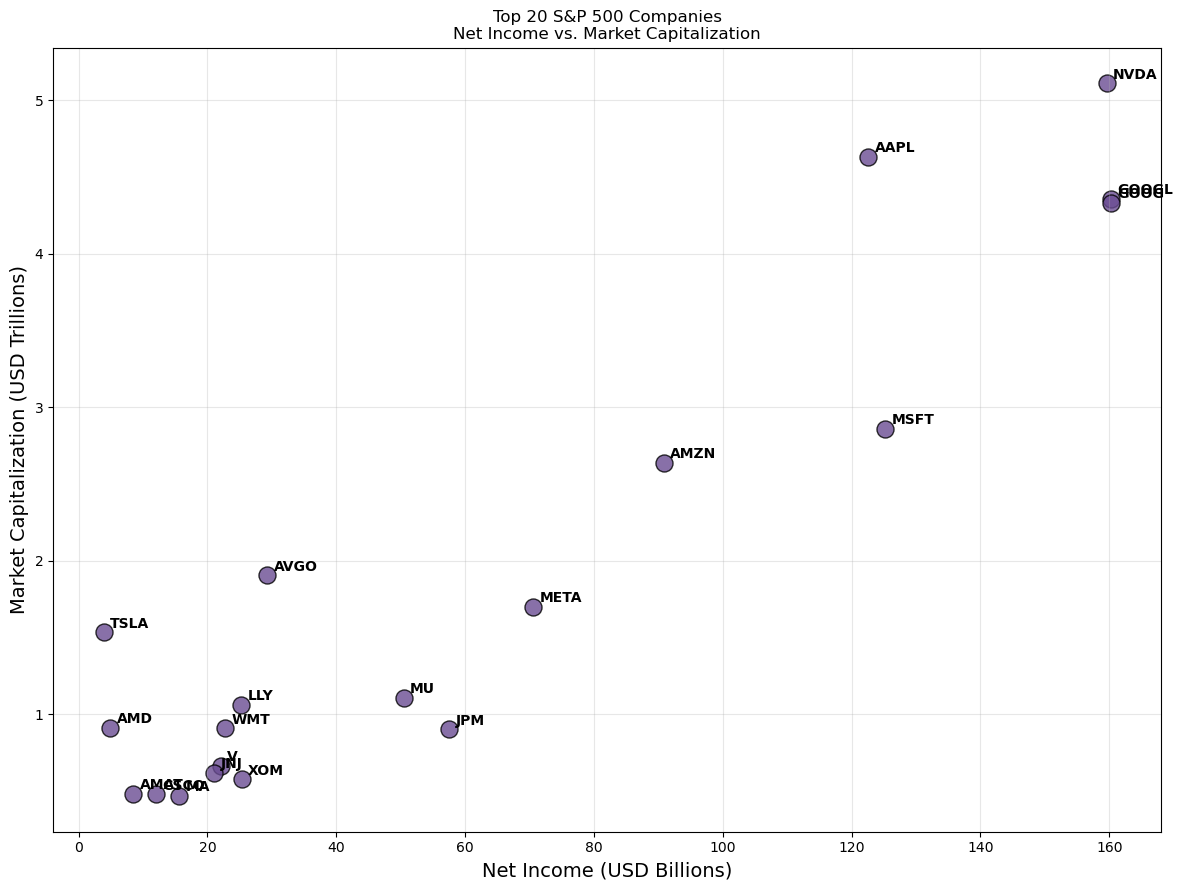

In [99]:
# Top 20 companies by market capitalization
top20 = financial_df.nlargest(20, "market_cap")

plt.figure(figsize=(12, 9))

plt.scatter(
    top20["net_income"] / 1e9,
    top20["market_cap"] / 1e12,
    s=150,
    color="#6A4C93",
    edgecolors="black",
    alpha=0.8
)

# Add ticker labels
for _, row in top20.iterrows():
    plt.text(
        row["net_income"] / 1e9 + 1,
        row["market_cap"] / 1e12 + 0.03,
        row["ticker"],
        fontsize=10,
        fontweight = "bold"
    )

plt.xlabel("Net Income (USD Billions)", fontsize = 14)
plt.ylabel("Market Capitalization (USD Trillions)", fontsize = 14)
plt.title("Top 20 S&P 500 Companies\nNet Income vs. Market Capitalization")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Observations

- Companies with higher net income generally tend to have higher market capitalizations, suggesting that profitability is more closely associated with company valuation than revenue alone.
- NVIDIA combines one of the highest net income levels with the highest market capitalization, while Apple, Microsoft, and Alphabet also cluster in the upper-right corner of the chart.
- Walmart provides an important contrast. Although it generated the highest revenue among the companies analyzed, its net income is substantially lower than that of the leading technology firms, which helps explain why its market capitalization is considerably lower despite its enormous sales.
- Amazon and Tesla demonstrate that profitability is not the only driver of market valuation. Although both companies have lower net income than NVIDIA, Apple, Microsoft, and Alphabet, their market capitalizations remain relatively high, suggesting that investors also value future growth prospects and long-term earnings potential.
- Overall, net income appears to have a stronger relationship with market capitalization than revenue, although other factors still contribute to investor valuation.

## 5.3 P/E Ratio Analysis

### **Do companies with higher P/E ratios tend to have higher market capitalizations?**

The previous section showed that profitability explains market capitalization better than revenue, but companies with similar net income can still receive very different market valuations. In this section, we examine whether the price-to-earnings (P/E) ratio helps explain these differences. The P/E ratio is calculated as Market Price per Share ÷ Earnings per Share (EPS) and reflects how much investors are willing to pay for each dollar of a company’s earnings. As a result, it provides insight into investors’ expectations for future growth.

In [90]:
financial_df["pe_ratio"].describe()

count   473.00
mean     38.56
std      53.08
min       3.54
25%      18.23
50%      26.52
75%      37.90
max     660.36
Name: pe_ratio, dtype: float64

In [91]:
financial_df[["company", "ticker", "pe_ratio"]].sort_values(
    "pe_ratio",
    ascending=False
).head(15)

,company,ticker,pe_ratio
139,"Datadog, Inc.",DDOG,660.36
129,"CoStar Group, Inc.",CSGP,405.57
312,Microchip Technology Incorporated,MCHP,402.68
436,"Tesla, Inc.",TSLA,370.69
357,Paramount Skydance Corporation,PSKY,313.67
356,"Palo Alto Networks, Inc.",PANW,285.89
218,Genuine Parts Company,GPC,285.50
55,"Axon Enterprise, Inc.",AXON,227.23
147,"Diamondback Energy, Inc.",FANG,189.06
6,"Advanced Micro Devices, Inc.",AMD,185.35


Most S&P 500 companies have P/E ratios between roughly 18 and 38, while a small number of companies exhibit extremely high P/E ratios. These unusually high values suggest that investors expect substantial future earnings growth rather than simply valuing current profitability.

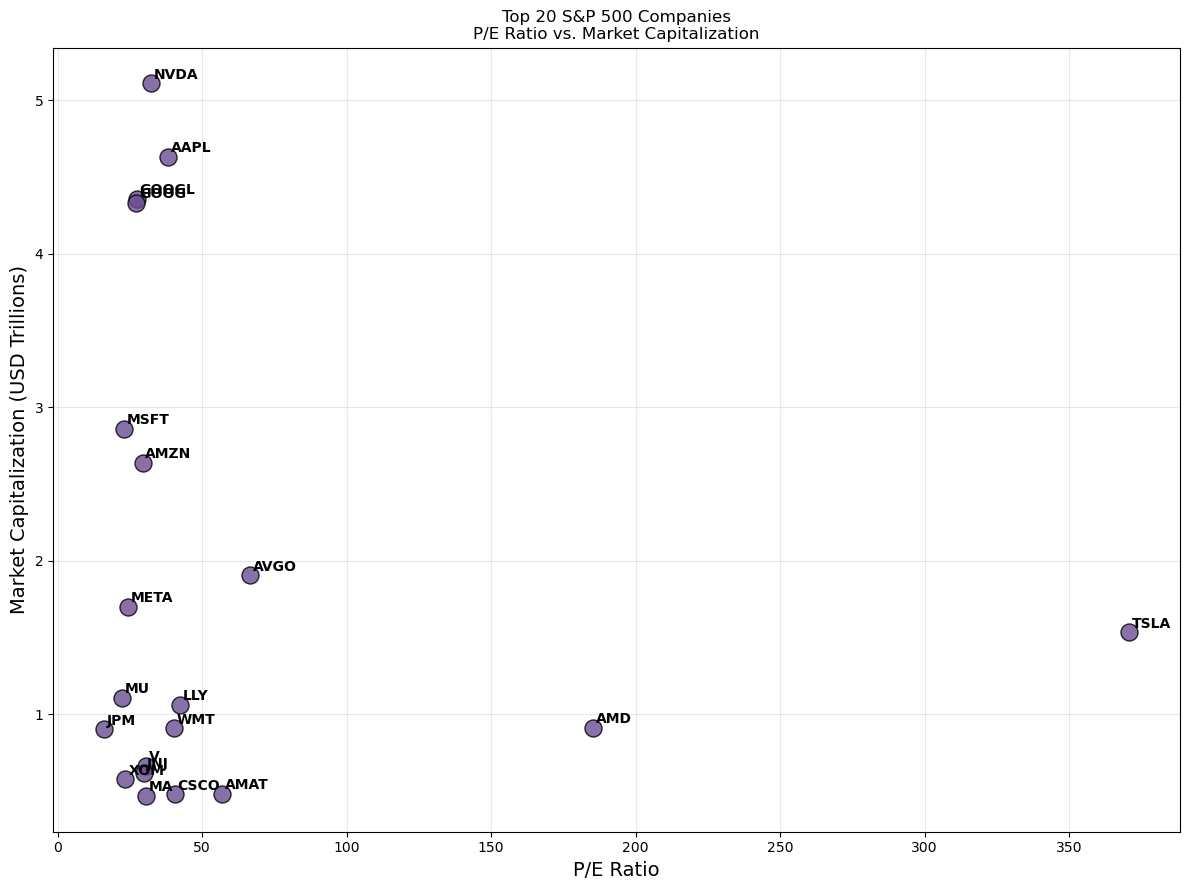

In [98]:
# Top 20 companies by market capitalization
top20 = financial_df.nlargest(20, "market_cap")

plt.figure(figsize=(12,9))

plt.scatter(
    top20["pe_ratio"],
    top20["market_cap"] / 1e12,
    s=150,
    color="#6A4C93",
    edgecolors="black",
    alpha=0.8
)

# Add ticker labels
for _, row in top20.iterrows():
    plt.text(
        row["pe_ratio"] + 1,
        row["market_cap"] / 1e12 + 0.03,
        row["ticker"],
        fontsize=10,
        fontweight = "bold"
    )

plt.xlabel("P/E Ratio", fontsize = 14)
plt.ylabel("Market Capitalization (USD Trillions)", fontsize = 14)
plt.title("Top 20 S&P 500 Companies\nP/E Ratio vs. Market Capitalization")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Observations

- Companies with higher P/E ratios do not necessarily have higher market capitalizations.
- NVIDIA, Apple, and Alphabet achieve the largest market valuations despite having relatively moderate P/E ratios compared with Tesla and AMD.
- Tesla and AMD stand out as high-P/E companies, reflecting strong investor expectations for future growth rather than current company size.
- Among the largest S&P 500 companies, the P/E ratio alone is not a reliable predictor of market capitalization.
- These findings suggest that market valuation reflects a combination of profitability, growth expectations, competitive position, and other company-specific factors rather than any single financial metric.

## 5.4 Distribution of Market Value Across Sectors

### **Where is the Market's Value Concentrated?**

The previous analyses focused on company-specific financial characteristics, including revenue, profitability, and valuation multiples. In this section, we examine whether market valuation also varies across sectors by comparing the distribution of market capitalization within the S&P 500.

In [105]:
# Calculate each sector's share of total S&P 500 market capitalization
sector_share = (
    financial_df
    .groupby("sector")["market_cap"]
    .sum()
    .sort_values(ascending=True)
)

sector_share_pct = sector_share / sector_share.sum() * 100

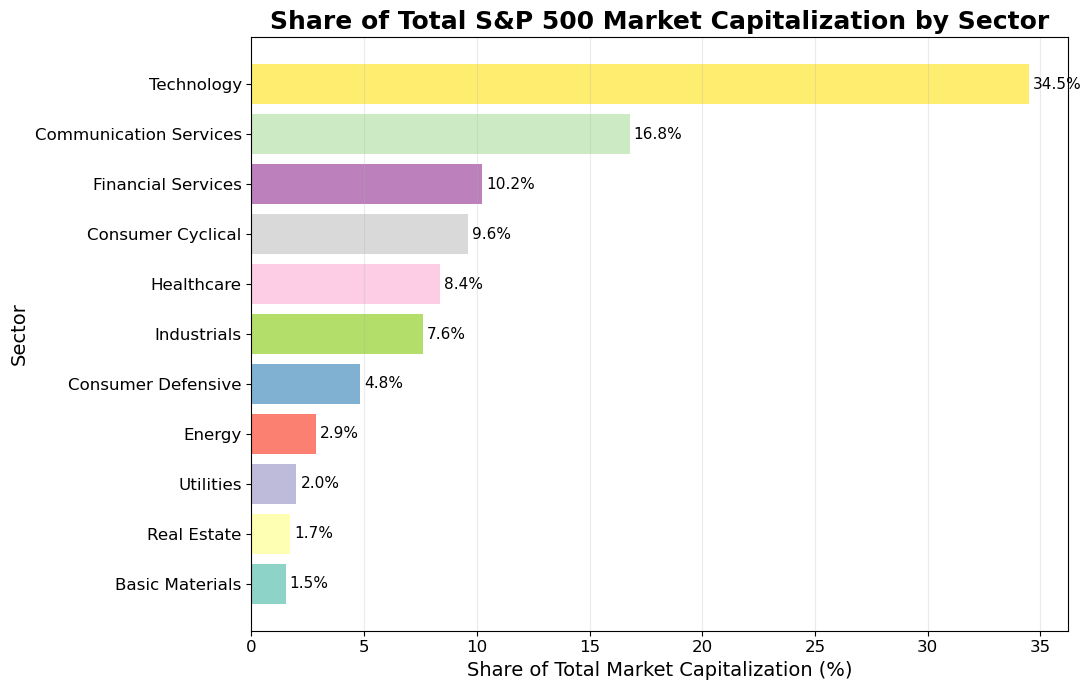

In [107]:
# Create a new figure for the visualization
plt.figure(figsize=(11, 7))

# Generate a different color for each sector
colors = plt.cm.Set3(
    np.linspace(0, 1, len(sector_share_pct))
)

# Create a horizontal bar chart showing each sector's share
# of the total S&P 500 market capitalization
bars = plt.barh(
    sector_share_pct.index,
    sector_share_pct.values,
    color=colors
)

# Add a descriptive chart title
plt.title(
    "Share of Total S&P 500 Market Capitalization by Sector",
    fontsize=18,
    fontweight="bold"
)

# Label the x-axis
plt.xlabel(
    "Share of Total Market Capitalization (%)",
    fontsize=14
)

# Label the y-axis
plt.ylabel(
    "Sector",
    fontsize=14
)

# Increase tick label font size for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display percentage labels at the end of each bar
plt.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=11
)

# Add light grid lines to improve readability
plt.grid(axis="x", alpha=0.25)

# Adjust spacing so labels fit nicely
plt.tight_layout()

# Display the final chart
plt.show()

In [108]:
!pip install plotly

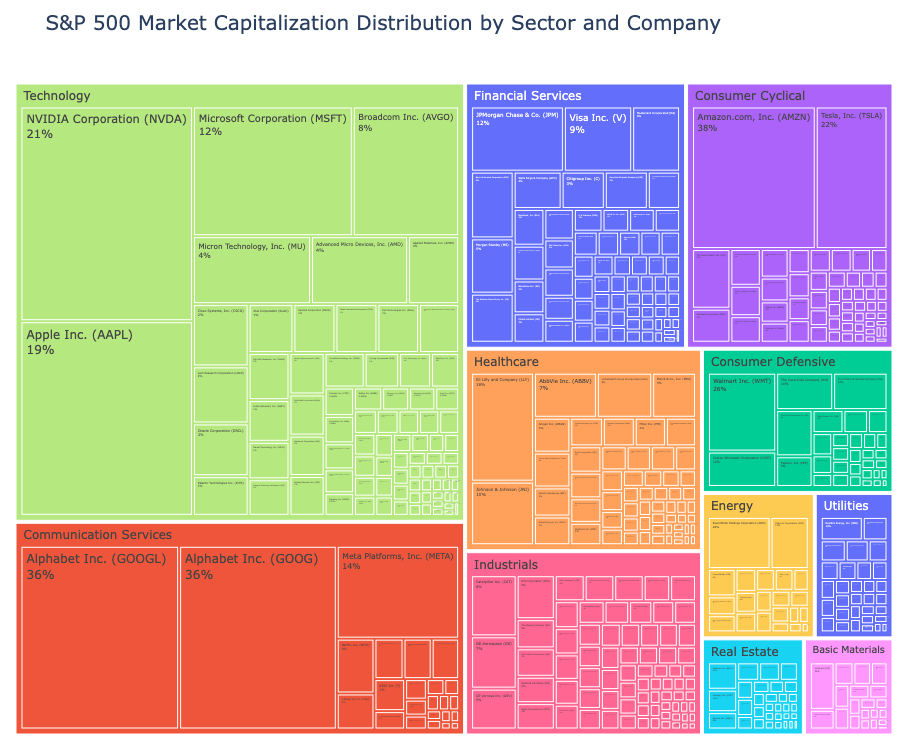

In [110]:
import plotly.express as px

# Keep only rows with the fields needed for the treemap
treemap_df = financial_df.dropna(
    subset=["sector", "company", "ticker", "market_cap"]
).copy()

# Create a label that combines company name and ticker
treemap_df["company_label"] = (
    treemap_df["company"] + " (" + treemap_df["ticker"] + ")"
)

# Create a hierarchical treemap:
# sector -> company
fig = px.treemap(
    treemap_df,
    path=["sector", "company_label"],
    values="market_cap",
    color="sector",
    title="S&P 500 Market Capitalization Distribution by Sector and Company"
)

fig.update_traces(
    textinfo="label+percent parent",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Market Capitalization: $%{value:,.0f}<br>"
        "Share of Parent: %{percentParent:.1%}"
        "<extra></extra>"
    )
)

fig.update_layout(
    title_font_size=20,
    margin=dict(t=60, l=10, r=10, b=10),
    height=750
)

fig.show()

### Key Observations

- Technology represents the largest share of total S&P 500 market capitalization, accounting for approximately 34.5% of the index. Communication Services follows with 16.8%, meaning these two sectors together represent more than half of the market’s total value.
- The treemap shows that this concentration is driven by a relatively small number of companies. Within Technology, NVIDIA, Apple, and Microsoft account for a substantial portion of the sector’s market value.
- Communication Services is similarly concentrated, with Alphabet (GOOGL and GOOG) and Meta representing the majority of the sector’s market capitalization.
- Other sectors, such as Financial Services, Healthcare, and Consumer Cyclical, are also dominated by a handful of large firms, including JPMorgan, Eli Lilly, Amazon, and Tesla.
- Overall, market capitalization is highly concentrated in a relatively small number of companies and sectors, illustrating that the S&P 500’s total market value is not evenly distributed across the economy.

## 6.💡 Key Insights

- **Market valuation is associated with multiple financial characteristics rather than a single metric.** Revenue, profitability, valuation multiples, and industry context all contribute to understanding company value.
- **Net income demonstrates a stronger relationship with market capitalization than revenue alone.** Companies with high profitability generally achieve higher market valuations, although profitability does not fully explain company value.
- **Revenue is not a reliable indicator of market valuation.** For example, Amazon and Walmart generate the highest revenues, yet they do not have the largest market capitalizations.
- **Investor expectations also influence market valuation.** Companies such as Tesla and AMD trade at relatively high P/E ratios, reflecting investors’ willingness to pay a premium for anticipated future growth, while NVIDIA illustrates how exceptional profitability combined with strong growth expectations can support the largest market capitalization.
- **Market value is highly concentrated.** Technology and Communication Services together account for more than half of the S&P 500’s total market capitalization, with a relatively small number of companies contributing a substantial share of the index’s overall value.

## ✅ Conclusion

This exploratory analysis examined the financial characteristics associated with market valuation across S&P 500 companies using data collected through the Yahoo Finance API. The visualizations revealed that market capitalization cannot be explained by any single financial metric. While revenue provides useful context, profitability (net income) demonstrates a stronger relationship with market valuation. At the same time, valuation multiples (P/E ratios) suggest that investors also incorporate future growth expectations when pricing companies. Finally, the analysis highlights that market value is concentrated within a relatively small number of sectors and companies, particularly in the Technology and Communication Services sectors. Overall, the findings suggest that market valuation reflects a combination of current financial performance, investor expectations, and broader market dynamics rather than any single measure.
